# KITTI and Pascal VOC dataset examples

Each figure contains one representative image for every object class. The coloured bounding box highlights the class named in the subplot title.

In [1]:
from pathlib import Path
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

def find_project_root():
    start = Path.cwd().resolve()
    for root in (start, *start.parents):
        if (root / 'datasets').is_dir():
            return root
    raise FileNotFoundError('Could not find the datasets directory.')

PROJECT_ROOT = find_project_root()

def read_yolo_labels(label_path):
    labels = []
    for line in label_path.read_text().splitlines():
        values = line.split()
        if len(values) >= 5:
            class_id = int(float(values[0]))
            x_center, y_center, width, height = map(float, values[1:5])
            labels.append((class_id, x_center, y_center, width, height))
    return labels

def find_representative_samples(dataset_root, splits, class_names):
    # Use a large bounding box so that each category is easy to see.
    best = {class_id: None for class_id in range(len(class_names))}
    extensions = ('.jpg', '.jpeg', '.png', '.bmp')
    for split in splits:
        label_dir = dataset_root / 'labels' / split
        image_dir = dataset_root / 'images' / split
        if not label_dir.is_dir() or not image_dir.is_dir():
            continue
        for label_path in sorted(label_dir.glob('*.txt')):
            labels = read_yolo_labels(label_path)
            if not labels:
                continue
            image_path = next((image_dir / f'{label_path.stem}{ext}' for ext in extensions
                               if (image_dir / f'{label_path.stem}{ext}').exists()), None)
            if image_path is None:
                continue
            for class_id, _, _, width, height in labels:
                if class_id in best:
                    area = width * height
                    if best[class_id] is None or area > best[class_id][0]:
                        best[class_id] = (area, image_path, labels)
    missing = [class_names[i] for i, sample in best.items() if sample is None]
    if missing:
        raise RuntimeError(f'No examples found for: {missing}')
    return best

def display_dataset(dataset_name, dataset_root, splits, class_names, columns=4, colour='#e63946'):
    samples = find_representative_samples(dataset_root, splits, class_names)
    rows = math.ceil(len(class_names) / columns)
    fig, axes = plt.subplots(rows, columns, figsize=(4.2 * columns, 3.2 * rows))
    axes = axes.ravel()
    for class_id, class_name in enumerate(class_names):
        _, image_path, labels = samples[class_id]
        image = Image.open(image_path).convert('RGB')
        image_width, image_height = image.size
        ax = axes[class_id]
        ax.imshow(image)
        for label_class, x_center, y_center, width, height in labels:
            if label_class != class_id:
                continue
            box_width, box_height = width * image_width, height * image_height
            x_min = x_center * image_width - box_width / 2
            y_min = y_center * image_height - box_height / 2
            ax.add_patch(Rectangle((x_min, y_min), box_width, box_height, fill=False,
                                   edgecolor=colour, linewidth=2.5))
        ax.set_title(f'{class_id}: {class_name}', fontsize=11, fontweight='bold')
        ax.set_xlabel(image_path.name, fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])
    for ax in axes[len(class_names):]:
        ax.axis('off')
    fig.suptitle(f'{dataset_name}: one example per class', fontsize=17, fontweight='bold')
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    plt.show()


## KITTI dataset

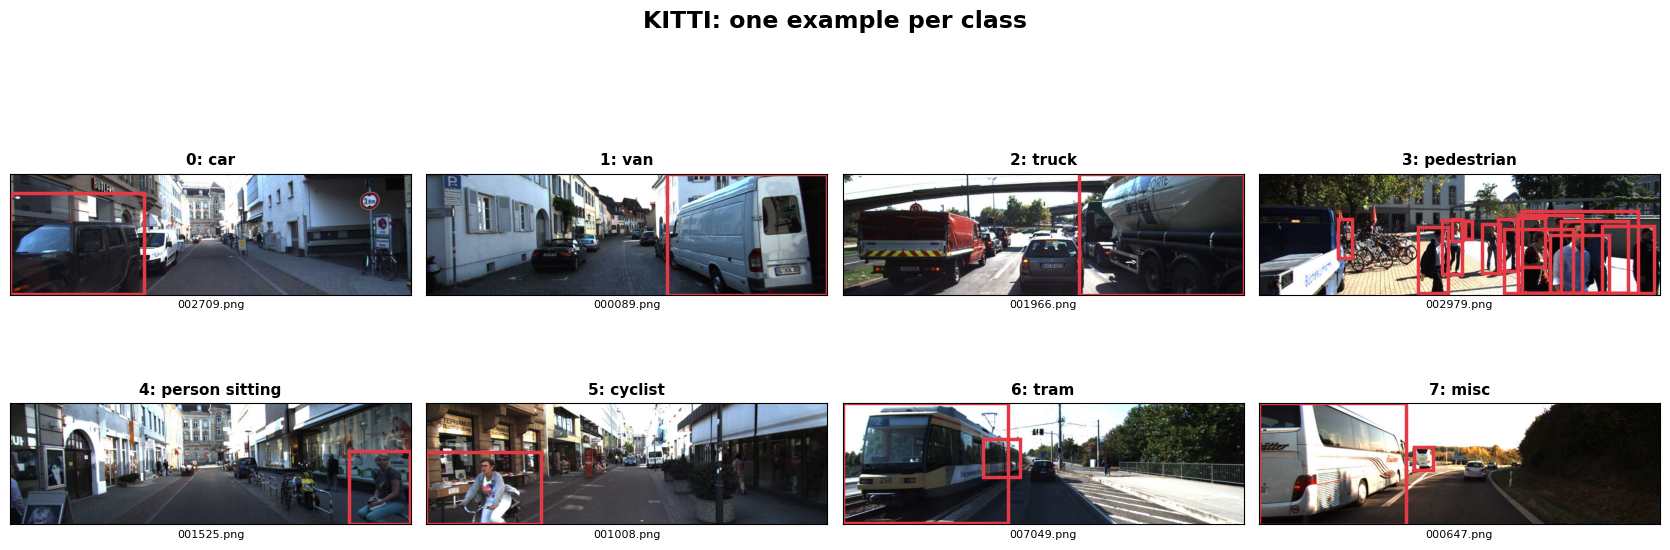

In [2]:
KITTI_CLASSES = [
    'car', 'van', 'truck', 'pedestrian',
    'person sitting', 'cyclist', 'tram', 'misc',
]
display_dataset(
    'KITTI', PROJECT_ROOT / 'datasets' / 'kitti', ['train', 'val'],
    KITTI_CLASSES, columns=4, colour='#e63946'
)

## Pascal VOC dataset

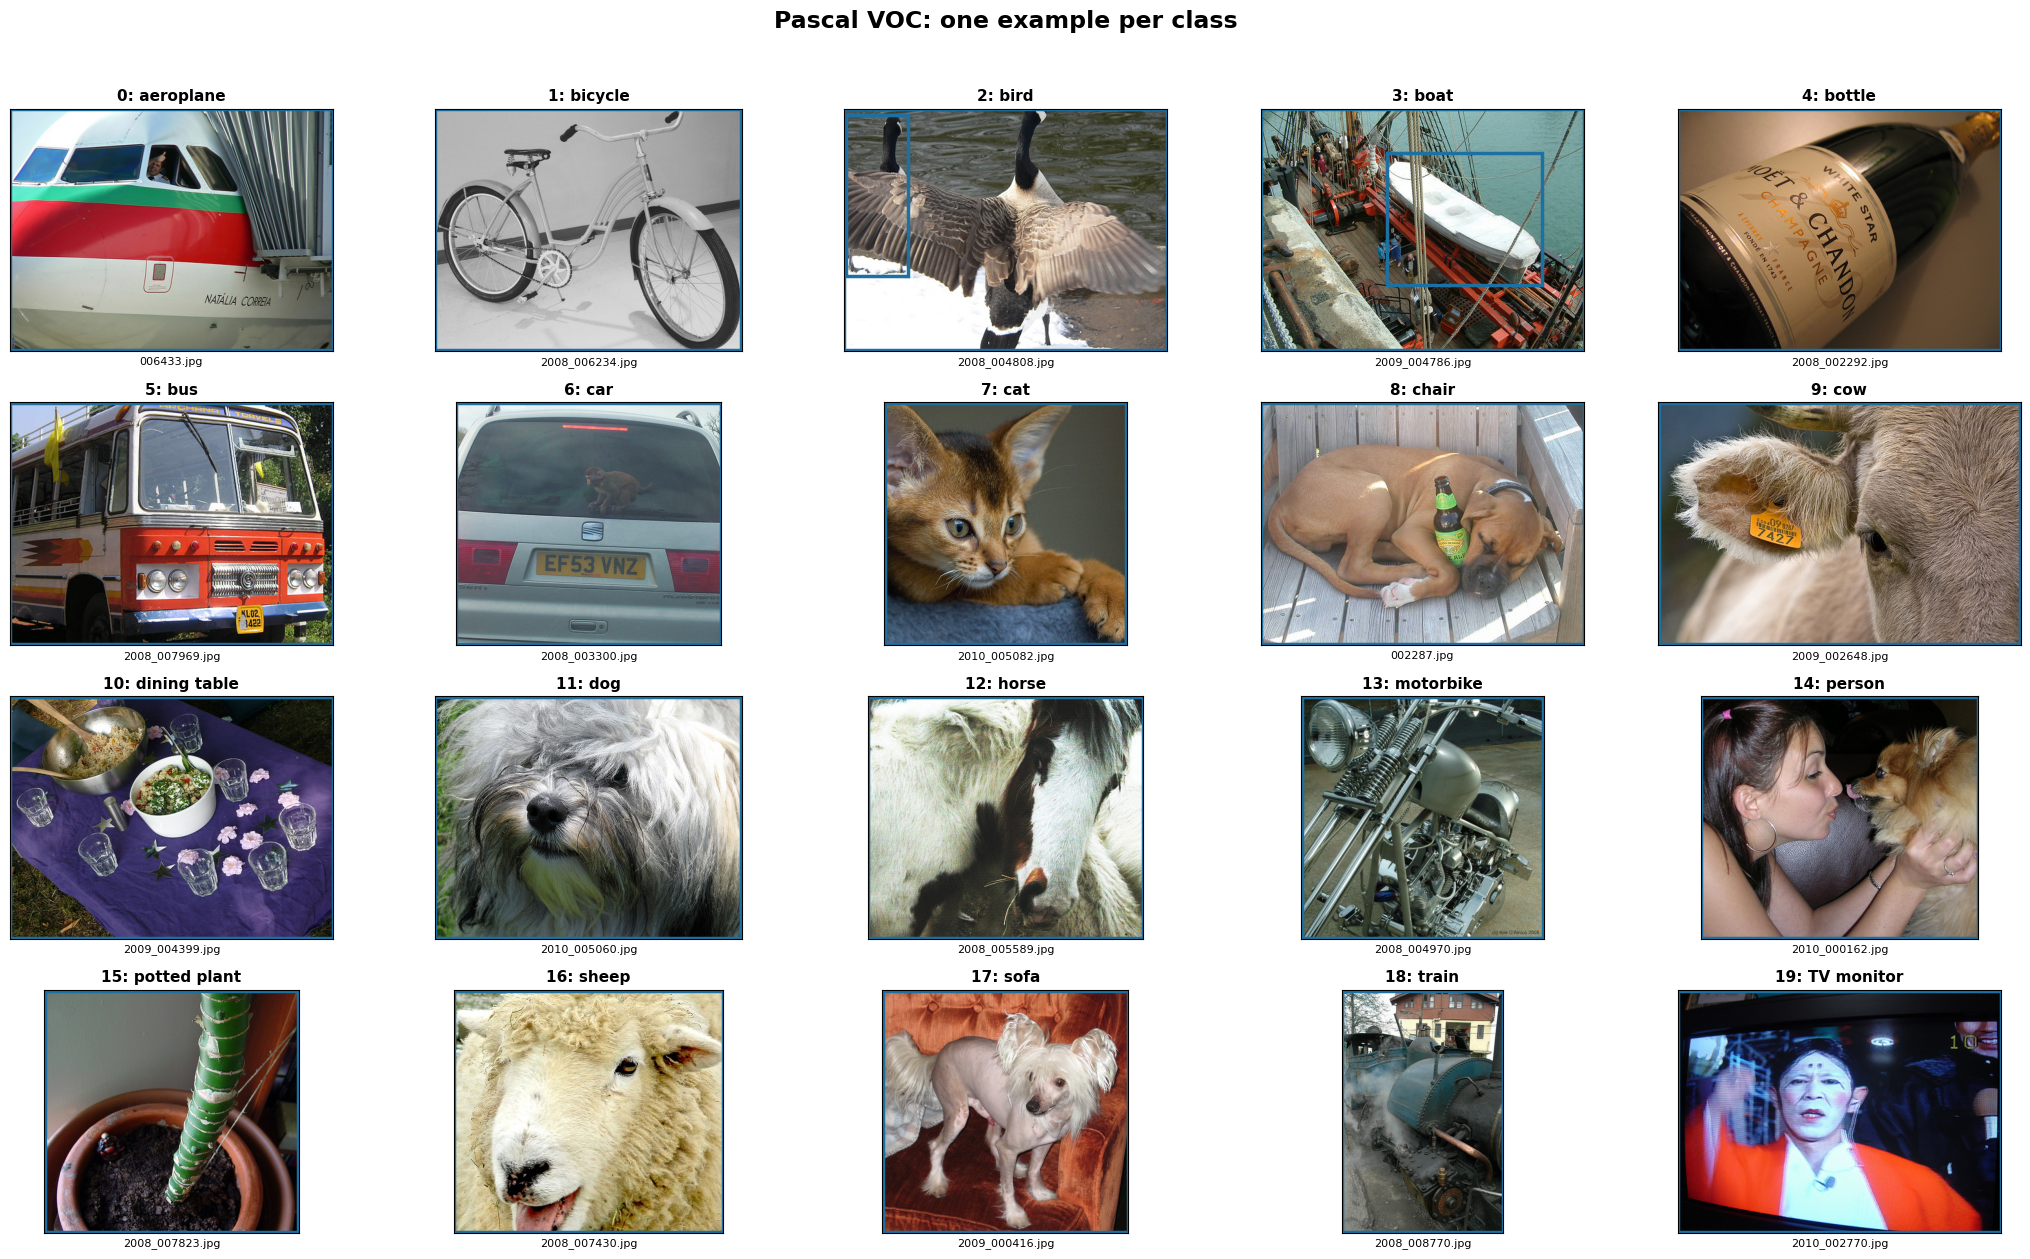

In [3]:
VOC_CLASSES = [
    'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
    'bus', 'car', 'cat', 'chair', 'cow',
    'dining table', 'dog', 'horse', 'motorbike', 'person',
    'potted plant', 'sheep', 'sofa', 'train', 'TV monitor',
]
display_dataset(
    'Pascal VOC', PROJECT_ROOT / 'datasets' / 'VOC',
    ['train2007', 'val2007', 'train2012', 'val2012', 'test2007'],
    VOC_CLASSES, columns=5, colour='#1d70a2'
)